# Building the Sufrace


In [1]:
import sys
import os

# Ascend 3 levels: tests -> volatility -> src -> Volatility-Surface
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [2]:
import pandas as pd
import numpy as np
from src.volatility.data.ingestion import select_snapshot, build_open_options
from src.volatility.market.forwards import infer_forward_by_maturity
from src.volatility.data.iv import compute_snapshot_iv
from src.volatility.data.datasets import build_ssvi_dataset
from src.volatility.calibration.fit_essiv import fit_essvi_surface
from src.volatility.calibration.fit_local import fit_localized_surface
from src.volatility.analysis.comparaison import print_comparison_summary
from src.volatility.visualization.diagnostics import plot_rmse_comparison, plot_term_structure_comparison
from src.volatility.visualization.smiles import plot_smile_comparison
from src.volatility.analysis.diagnostics import compute_fd_atm_skew, compute_atm_forward_skew
from src.volatility.visualization.diagnostics import plot_power_law_term_structure
from src.volatility.visualization.smiles import _C

In [3]:


data_path = os.path.join(project_root, "data", "combined_options_data.csv")
df_raw = pd.read_csv(data_path)
df_raw["QUOTE_DATE"] = pd.to_datetime(df_raw["QUOTE_DATE"], dayfirst=True, errors="coerce")

df_raw

,QUOTE_UNIXTIME,QUOTE_READTIME,QUOTE_DATE,QUOTE_TIME_HOURS,UNDERLYING_LAST,EXPIRE_DATE,EXPIRE_UNIX,DTE,C_DELTA,C_GAMMA,...,P_SIZE,P_LAST,P_DELTA,P_GAMMA,P_VEGA,P_THETA,P_RHO,P_IV,P_VOLUME,STRIKE_DISTANCE
0,1262638800,04-01-2010 16:00,2010-01-04,16,1132.99,07-01-2010,1262898000,3.0,1.00000,0.00000,...,0 x 420,0.05,-0.00077,0.00004,0.00439,-0.02116,-0.00049,0.64013,550.0,208.0
1,1262638800,04-01-2010 16:00,2010-01-04,16,1132.99,07-01-2010,1262898000,3.0,1.00000,0.00000,...,0 x 455,0.05,-0.00203,0.00006,0.00911,-0.04056,0.00000,0.59859,NaN,183.0
2,1262638800,04-01-2010 16:00,2010-01-04,16,1132.99,07-01-2010,1262898000,3.0,1.00000,0.00000,...,717 x 177,0.10,-0.00369,0.00022,0.01302,-0.05898,-0.00071,0.53885,NaN,158.0
3,1262638800,04-01-2010 16:00,2010-01-04,16,1132.99,07-01-2010,1262898000,3.0,1.00000,0.00000,...,470 x 98,0.15,-0.00894,0.00038,0.02786,-0.12758,-0.00086,0.50273,NaN,133.0
4,1262638800,04-01-2010 16:00,2010-01-04,16,1132.99,07-01-2010,1262898000,3.0,1.00000,0.00000,...,428 x 63,0.20,-0.01251,0.00066,0.03857,-0.15692,-0.00147,0.42725,720.0,108.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048526,1376683200,16-08-2013 16:00,2013-08-16,16,1655.93,30-08-2013,1377892800,14.0,0.16747,0.00665,...,116 x 70,36.13,-0.90826,0.00585,0.54294,-0.36616,-0.63390,0.08241,6.0,34.1
1048527,1376683200,16-08-2013 16:00,2013-08-16,16,1655.93,30-08-2013,1377892800,14.0,0.13202,0.00572,...,181 x 60,0.00,-0.96939,0.00299,0.21930,-0.27911,-0.67714,0.06541,NaN,39.1
1048528,1376683200,16-08-2013 16:00,2013-08-16,16,1655.93,30-08-2013,1377892800,14.0,0.10025,0.00479,...,181 x 60,45.70,-1.00000,0.00000,-450.70007,0.00000,0.00000,0.00035,5.0,44.1
1048529,1376683200,16-08-2013 16:00,2013-08-16,16,1655.93,30-08-2013,1377892800,14.0,0.07571,0.00398,...,25 x 25,46.74,-1.00000,0.00000,-500.69973,0.00000,0.00000,0.00093,5.0,49.1


In [4]:
snap = select_snapshot(df_raw, snapshot_index="2012-01-01", date_col="QUOTE_DATE")
snap

,QUOTE_UNIXTIME,QUOTE_READTIME,QUOTE_DATE,QUOTE_TIME_HOURS,UNDERLYING_LAST,EXPIRE_DATE,EXPIRE_UNIX,DTE,C_DELTA,C_GAMMA,...,P_LAST,P_DELTA,P_GAMMA,P_VEGA,P_THETA,P_RHO,P_IV,P_VOLUME,STRIKE_DISTANCE,SNAPSHOT_DATE
0,1262638800,04-01-2010 16:00,2010-01-04,16,1132.99,07-01-2010,1262898000,3.0,1.00000,0.00000,...,0.05,-0.00077,0.00004,0.00439,-0.02116,-0.00049,0.64013,550.0,208.0,2011-12-30
1,1262638800,04-01-2010 16:00,2010-01-04,16,1132.99,07-01-2010,1262898000,3.0,1.00000,0.00000,...,0.05,-0.00203,0.00006,0.00911,-0.04056,0.00000,0.59859,NaN,183.0,2011-12-30
2,1262638800,04-01-2010 16:00,2010-01-04,16,1132.99,07-01-2010,1262898000,3.0,1.00000,0.00000,...,0.10,-0.00369,0.00022,0.01302,-0.05898,-0.00071,0.53885,NaN,158.0,2011-12-30
3,1262638800,04-01-2010 16:00,2010-01-04,16,1132.99,07-01-2010,1262898000,3.0,1.00000,0.00000,...,0.15,-0.00894,0.00038,0.02786,-0.12758,-0.00086,0.50273,NaN,133.0,2011-12-30
4,1262638800,04-01-2010 16:00,2010-01-04,16,1132.99,07-01-2010,1262898000,3.0,1.00000,0.00000,...,0.20,-0.01251,0.00066,0.03857,-0.15692,-0.00147,0.42725,720.0,108.0,2011-12-30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
481625,1325278800,30-12-2011 16:00,2011-12-30,16,1257.91,18-12-2014,1418936400,1084.0,0.03400,0.00023,...,0.00,-0.94657,0.00000,0.00000,-0.06022,-62.36523,-0.00009,NaN,842.1,2011-12-30
481626,1325278800,30-12-2011 16:00,2011-12-30,16,1257.91,18-12-2014,1418936400,1084.0,0.02074,0.00013,...,0.00,-0.94622,0.00000,0.00000,-0.06021,-65.33411,-0.00019,NaN,942.1,2011-12-30
481627,1325278800,30-12-2011 16:00,2011-12-30,16,1257.91,18-12-2014,1418936400,1084.0,0.01611,0.00014,...,0.00,-0.94568,0.00000,0.00000,-0.06011,-66.81953,-0.00040,NaN,992.1,2011-12-30
481628,1325278800,30-12-2011 16:00,2011-12-30,16,1257.91,18-12-2014,1418936400,1084.0,0.00616,0.00005,...,1265.35,-0.94652,0.00000,0.00000,-0.06021,-74.13313,0.00016,6.0,1242.1,2011-12-30


In [5]:
open_opt = build_open_options(snap)
open_opt

,STRIKE,EXPIRY_DATE,QUOTE_UNIXTIME,QUOTE_READTIME,QUOTE_DATE,QUOTE_TIME_HOURS,UNDERLYING_LAST,EXPIRE_DATE,EXPIRE_UNIX,DTE,...,P_VEGA,P_THETA,P_RHO,P_IV,P_VOLUME,STRIKE_DISTANCE,SNAPSHOT_DATE,T,T_days,UNDERLYING_AT_TARGET
0,100,2012-02-16 00:00:00,1325278800,30-12-2011 16:00,2011-12-30,16,1257.91,16-02-2012,1329426000,48.00,...,0.00157,-0.00346,-0.00030,2.05511,0.0,1157.9,2011-12-30,0.131507,48,1257.91
1,100,2012-02-16 00:57:36,1320436800,04-11-2011 16:00,2011-11-04,16,1253.01,16-02-2012,1329426000,104.04,...,0.00779,-0.00583,-0.00133,1.56158,NaN,1153.0,2011-12-30,0.131507,48,1257.91
2,100,2012-06-13 23:02:24,1325278800,30-12-2011 16:00,2011-12-30,16,1257.91,14-06-2012,1339704000,166.96,...,0.00569,-0.00212,-0.00081,1.16669,0.0,1157.9,2011-12-30,0.454795,166,1257.91
3,100,2012-06-14 00:00:00,1320436800,04-11-2011 16:00,2011-11-04,16,1253.01,14-06-2012,1339704000,223.00,...,0.01097,-0.00214,-0.00334,1.06669,0.0,1153.0,2011-12-30,0.457534,167,1257.91
4,100,2012-09-19 23:02:24,1325278800,30-12-2011 16:00,2011-12-30,16,1257.91,20-09-2012,1348171200,264.96,...,0.00900,-0.00141,-0.00226,0.95594,0.0,1157.9,2011-12-30,0.723288,264,1257.91
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1544,3000,2012-12-20 00:00:00,1325278800,30-12-2011 16:00,2011-12-30,16,1257.91,20-12-2012,1356037200,356.00,...,239.26574,0.00000,0.00000,-0.00001,0.0,1742.1,2011-12-30,0.975342,356,1257.91
1545,3000,2012-12-20 00:57:36,1320436800,04-11-2011 16:00,2011-11-04,16,1253.01,20-12-2012,1356037200,412.04,...,275.63278,0.00000,0.00000,-0.00018,0.0,1747.0,2011-12-30,0.975342,356,1257.91
1546,3000,2013-12-19 00:00:00,1325278800,30-12-2011 16:00,2011-12-30,16,1257.91,19-12-2013,1387486800,720.00,...,472.59789,0.00000,0.00000,0.00048,0.0,1742.1,2011-12-30,1.972603,720,1257.91
1547,3000,2013-12-19 00:57:36,1320436800,04-11-2011 16:00,2011-11-04,16,1253.01,19-12-2013,1387486800,776.04,...,0.00000,-0.06521,-63.73894,0.00005,0.0,1747.0,2011-12-30,1.972603,720,1257.91


In [6]:
parity   = infer_forward_by_maturity(open_opt)
parity

,T_days,T,F_parity,D_parity,n_pairs
0,7,0.019178,1256.462855,0.998256,29
1,20,0.054795,1248.036960,0.997602,96
2,48,0.131507,1253.739171,0.994938,74
3,75,0.205479,1252.010394,0.998836,75
4,76,0.208219,1243.471295,0.998032,44
5,90,0.246575,1251.615164,0.999655,19
6,91,0.249315,1242.984424,0.998130,15
7,110,0.301370,1250.569856,0.999183,16
8,166,0.454795,1246.979399,0.997370,28
9,167,0.457534,1238.291944,0.996904,36


In [7]:
open_opt = open_opt.merge(parity[["T_days","F_parity","D_parity"]], on="T_days", how="left")
open_opt

,STRIKE,EXPIRY_DATE,QUOTE_UNIXTIME,QUOTE_READTIME,QUOTE_DATE,QUOTE_TIME_HOURS,UNDERLYING_LAST,EXPIRE_DATE,EXPIRE_UNIX,DTE,...,P_RHO,P_IV,P_VOLUME,STRIKE_DISTANCE,SNAPSHOT_DATE,T,T_days,UNDERLYING_AT_TARGET,F_parity,D_parity
0,100,2012-02-16 00:00:00,1325278800,30-12-2011 16:00,2011-12-30,16,1257.91,16-02-2012,1329426000,48.00,...,-0.00030,2.05511,0.0,1157.9,2011-12-30,0.131507,48,1257.91,1253.739171,0.994938
1,100,2012-02-16 00:57:36,1320436800,04-11-2011 16:00,2011-11-04,16,1253.01,16-02-2012,1329426000,104.04,...,-0.00133,1.56158,NaN,1153.0,2011-12-30,0.131507,48,1257.91,1253.739171,0.994938
2,100,2012-06-13 23:02:24,1325278800,30-12-2011 16:00,2011-12-30,16,1257.91,14-06-2012,1339704000,166.96,...,-0.00081,1.16669,0.0,1157.9,2011-12-30,0.454795,166,1257.91,1246.979399,0.997370
3,100,2012-06-14 00:00:00,1320436800,04-11-2011 16:00,2011-11-04,16,1253.01,14-06-2012,1339704000,223.00,...,-0.00334,1.06669,0.0,1153.0,2011-12-30,0.457534,167,1257.91,1238.291944,0.996904
4,100,2012-09-19 23:02:24,1325278800,30-12-2011 16:00,2011-12-30,16,1257.91,20-09-2012,1348171200,264.96,...,-0.00226,0.95594,0.0,1157.9,2011-12-30,0.723288,264,1257.91,1241.597958,0.995537
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1544,3000,2012-12-20 00:00:00,1325278800,30-12-2011 16:00,2011-12-30,16,1257.91,20-12-2012,1356037200,356.00,...,0.00000,-0.00001,0.0,1742.1,2011-12-30,0.975342,356,1257.91,1233.240138,0.986307
1545,3000,2012-12-20 00:57:36,1320436800,04-11-2011 16:00,2011-11-04,16,1253.01,20-12-2012,1356037200,412.04,...,0.00000,-0.00018,0.0,1747.0,2011-12-30,0.975342,356,1257.91,1233.240138,0.986307
1546,3000,2013-12-19 00:00:00,1325278800,30-12-2011 16:00,2011-12-30,16,1257.91,19-12-2013,1387486800,720.00,...,0.00000,0.00048,0.0,1742.1,2011-12-30,1.972603,720,1257.91,1205.810168,0.987969
1547,3000,2013-12-19 00:57:36,1320436800,04-11-2011 16:00,2011-11-04,16,1253.01,19-12-2013,1387486800,776.04,...,-63.73894,0.00005,0.0,1747.0,2011-12-30,1.972603,720,1257.91,1205.810168,0.987969


In [8]:
open_opt = compute_snapshot_iv(open_opt)
open_opt

,STRIKE,EXPIRY_DATE,QUOTE_UNIXTIME,QUOTE_READTIME,QUOTE_DATE,QUOTE_TIME_HOURS,UNDERLYING_LAST,EXPIRE_DATE,EXPIRE_UNIX,DTE,...,call_price,put_price,call_iv,put_iv,call_rel_spread,put_rel_spread,call_method,put_method,call_oi,put_oi
0,100,2012-02-16 00:00:00,1325278800,30-12-2011 16:00,2011-12-30,16,1257.91,16-02-2012,1329426000,48.00,...,1153.150,0.050,3.794780,2.185524,0.003902,NaN,mid,last,NaN,NaN
1,100,2012-02-16 00:57:36,1320436800,04-11-2011 16:00,2011-11-04,16,1253.01,16-02-2012,1329426000,104.04,...,1144.055,NaN,NaN,NaN,0.003068,NaN,mid,missing,NaN,NaN
2,100,2012-06-13 23:02:24,1325278800,30-12-2011 16:00,2011-12-30,16,1257.91,14-06-2012,1339704000,166.96,...,1143.595,0.100,NaN,1.242070,0.005238,NaN,mid,last,NaN,NaN
3,100,2012-06-14 00:00:00,1320436800,04-11-2011 16:00,2011-11-04,16,1253.01,14-06-2012,1339704000,223.00,...,1135.350,0.100,1.472680,1.235591,0.003435,NaN,mid,last,NaN,NaN
4,100,2012-09-19 23:02:24,1325278800,30-12-2011 16:00,2011-12-30,16,1257.91,20-09-2012,1348171200,264.96,...,569.650,0.075,NaN,0.959925,1.999614,0.666667,mid,mid,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1544,3000,2012-12-20 00:00:00,1325278800,30-12-2011 16:00,2011-12-30,16,1257.91,20-12-2012,1356037200,356.00,...,0.050,1752.905,0.267748,0.479738,NaN,0.004330,last,mid,NaN,NaN
1545,3000,2012-12-20 00:57:36,1320436800,04-11-2011 16:00,2011-11-04,16,1253.01,20-12-2012,1356037200,412.04,...,0.050,1761.950,0.267748,0.539222,NaN,0.004030,last,mid,NaN,NaN
1546,3000,2013-12-19 00:00:00,1325278800,30-12-2011 16:00,2011-12-30,16,1257.91,19-12-2013,1387486800,720.00,...,0.200,1760.445,0.214894,NaN,1.500000,0.004380,mid,mid,NaN,NaN
1547,3000,2013-12-19 00:57:36,1320436800,04-11-2011 16:00,2011-11-04,16,1253.01,19-12-2013,1387486800,776.04,...,0.200,1772.705,0.214894,0.203149,1.500000,0.004180,mid,mid,NaN,NaN


In [9]:
df_smile = build_ssvi_dataset(open_opt)

In [10]:
df_smile

,STRIKE,EXPIRY_DATE,QUOTE_UNIXTIME,QUOTE_READTIME,QUOTE_DATE,QUOTE_TIME_HOURS,UNDERLYING_LAST,EXPIRE_DATE,EXPIRE_UNIX,DTE,...,call_method,put_method,call_oi,put_oi,k,total_variance,IV,REL_SPREAD,OI,SIDE
0,100,2012-02-16 00:00:00,1325278800,30-12-2011 16:00,2011-12-30,16,1257.91,16-02-2012,1329426000,48.00,...,mid,last,NaN,NaN,-2.528716,0.628145,2.185524,NaN,NaN,put
1,100,2012-06-13 23:02:24,1325278800,30-12-2011 16:00,2011-12-30,16,1257.91,14-06-2012,1339704000,166.96,...,mid,last,NaN,NaN,-2.523309,0.701628,1.242070,NaN,NaN,put
2,100,2012-06-14 00:00:00,1320436800,04-11-2011 16:00,2011-11-04,16,1253.01,14-06-2012,1339704000,223.00,...,mid,last,NaN,NaN,-2.516318,0.698511,1.235591,NaN,NaN,put
3,100,2012-09-20 00:00:00,1320436800,04-11-2011 16:00,2011-11-04,16,1253.01,20-09-2012,1348171200,321.00,...,mid,last,NaN,NaN,-2.511717,0.825867,1.066543,NaN,NaN,put
4,150,2012-01-19 00:00:00,1325278800,30-12-2011 16:00,2011-12-30,16,1257.91,19-01-2012,1327006800,20.00,...,mid,last,NaN,NaN,-2.118692,0.437740,2.826439,NaN,NaN,put
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1011,2500,2012-12-20 00:57:36,1320436800,04-11-2011 16:00,2011-11-04,16,1253.01,20-12-2012,1356037200,412.04,...,last,mid,NaN,NaN,0.706646,0.046283,0.217837,NaN,NaN,call
1012,3000,2012-06-13 23:02:24,1325278800,30-12-2011 16:00,2011-12-30,16,1257.91,14-06-2012,1339704000,166.96,...,last,mid,NaN,NaN,0.877888,0.080669,0.421159,NaN,NaN,call
1013,3000,2012-06-14 00:00:00,1320436800,04-11-2011 16:00,2011-11-04,16,1253.01,14-06-2012,1339704000,223.00,...,last,mid,NaN,NaN,0.884879,0.081907,0.423107,NaN,NaN,call
1014,3000,2012-12-20 00:00:00,1325278800,30-12-2011 16:00,2011-12-30,16,1257.91,20-12-2012,1356037200,356.00,...,last,mid,NaN,NaN,0.888967,0.069922,0.267748,NaN,NaN,call


# Calibrating the Surface


In [11]:
fit_essvi = fit_essvi_surface(df_smile)
fit_essvi

{'method': 'eSSVI',
 'T_knots': array([0.01917808, 0.05479452, 0.13150685, 0.20547945, 0.20821918,
        0.24657534, 0.24931507, 0.30136986, 0.45479452, 0.45753425,
        0.49589041, 0.49863014, 0.72328767, 0.7260274 , 0.74520548,
        0.74794521, 0.97534247, 1.47123288, 1.4739726 , 1.97260274,
        2.96986301]),
 'theta_knots': array([2.08508770e-05, 5.86551011e-03, 8.40604320e-03, 8.71990695e-03,
        1.94290980e-02, 1.94290981e-02, 1.94291498e-02, 1.94291501e-02,
        2.52848871e-02, 3.65220152e-02, 3.65220154e-02, 4.31483066e-02,
        4.31483070e-02, 5.36484515e-02, 5.36484516e-02, 6.35103543e-02,
        6.91439023e-02, 9.31522901e-02, 1.18755021e-01, 1.44017711e-01,
        2.22559684e-01]),
 'rho_inf': -0.9999999920576669,
 'rho_0': -0.5200612979267876,
 'c_rho': 7.400595077160684,
 'eta': 0.515804240267862,
 'gamma': 0.7363190394016029,
 'rmse_total_var': 0.02447218839214814,
 'mae_total_var': 0.010478516351844465,
 'summary':            T     theta     rho_T

In [12]:
fit_local = fit_localized_surface(df_smile)
fit_local


{'method': 'Localized Quadratic',
 'summary':     T_days         T         a         b         c    atm_iv  atm_skew  \
 0        7  0.019178  0.000545 -0.005389  0.087106  0.168593 -0.833396   
 1       20  0.054795  0.009198 -0.042201  0.059062  0.409708 -0.939898   
 2       48  0.131507  0.009699 -0.055362  0.073891  0.271568 -0.775093   
 3       75  0.205479  0.011441 -0.044304  0.077966  0.235963 -0.456874   
 4       76  0.208219  0.025797 -0.097171  0.075472  0.351988 -0.662913   
 5       90  0.246575  0.013423 -0.051912  0.130833  0.233318 -0.451169   
 6       91  0.249315  0.028362 -0.088704  0.131483  0.337286 -0.527433   
 7      110  0.301370  0.016996 -0.074418  0.054509  0.237477 -0.519905   
 8      166  0.454795  0.028219 -0.067470  0.085453  0.249094 -0.297786   
 9      167  0.457534  0.045756 -0.114336  0.058767  0.316238 -0.395109   
 10     181  0.495890  0.029395 -0.098815  0.069187  0.243468 -0.409226   
 11     182  0.498630  0.046799 -0.142182  0.061002  0.

# diagnostics


In [13]:
print_comparison_summary(fit_essvi, fit_local)


Method                        RMSE (×10⁴)       MAE (×10⁴)
----------------------------------------------------------
eSSVI                            244.7219         104.7852
Localized Quadratic               73.2104          46.8444

eSSVI global params:
  ρ₀   = -0.5201  ← short-maturity correlation
  ρ∞   = -1.0000  ← long-maturity correlation
  c    = 7.4006   ← transition speed in θ-space
  η    = 0.5158   ← vol-of-vol scaling
  γ    = 0.7363   ← power-law exponent

eSSVI per-maturity:
     T  theta   rho_T     phi_T  atm_iv  atm_skew
0.0192 0.0000 -0.5201 1442.4567  0.0330  -12.3694
0.0548 0.0059 -0.5404   22.6842  0.3272   -2.0055
0.1315 0.0084 -0.5490   17.4039  0.2528   -1.2079
0.2055 0.0087 -0.5501   16.9405  0.2060   -0.9598
0.2082 0.0194 -0.5843    9.3914  0.3055   -0.8382
0.2466 0.0194 -0.5843    9.3914  0.2807   -0.7702
0.2493 0.0194 -0.5843    9.3914  0.2792   -0.7660
0.3014 0.0194 -0.5843    9.3914  0.2539   -0.6967
0.4548 0.0253 -0.6020    7.7355  0.2358   -0.5490
0.

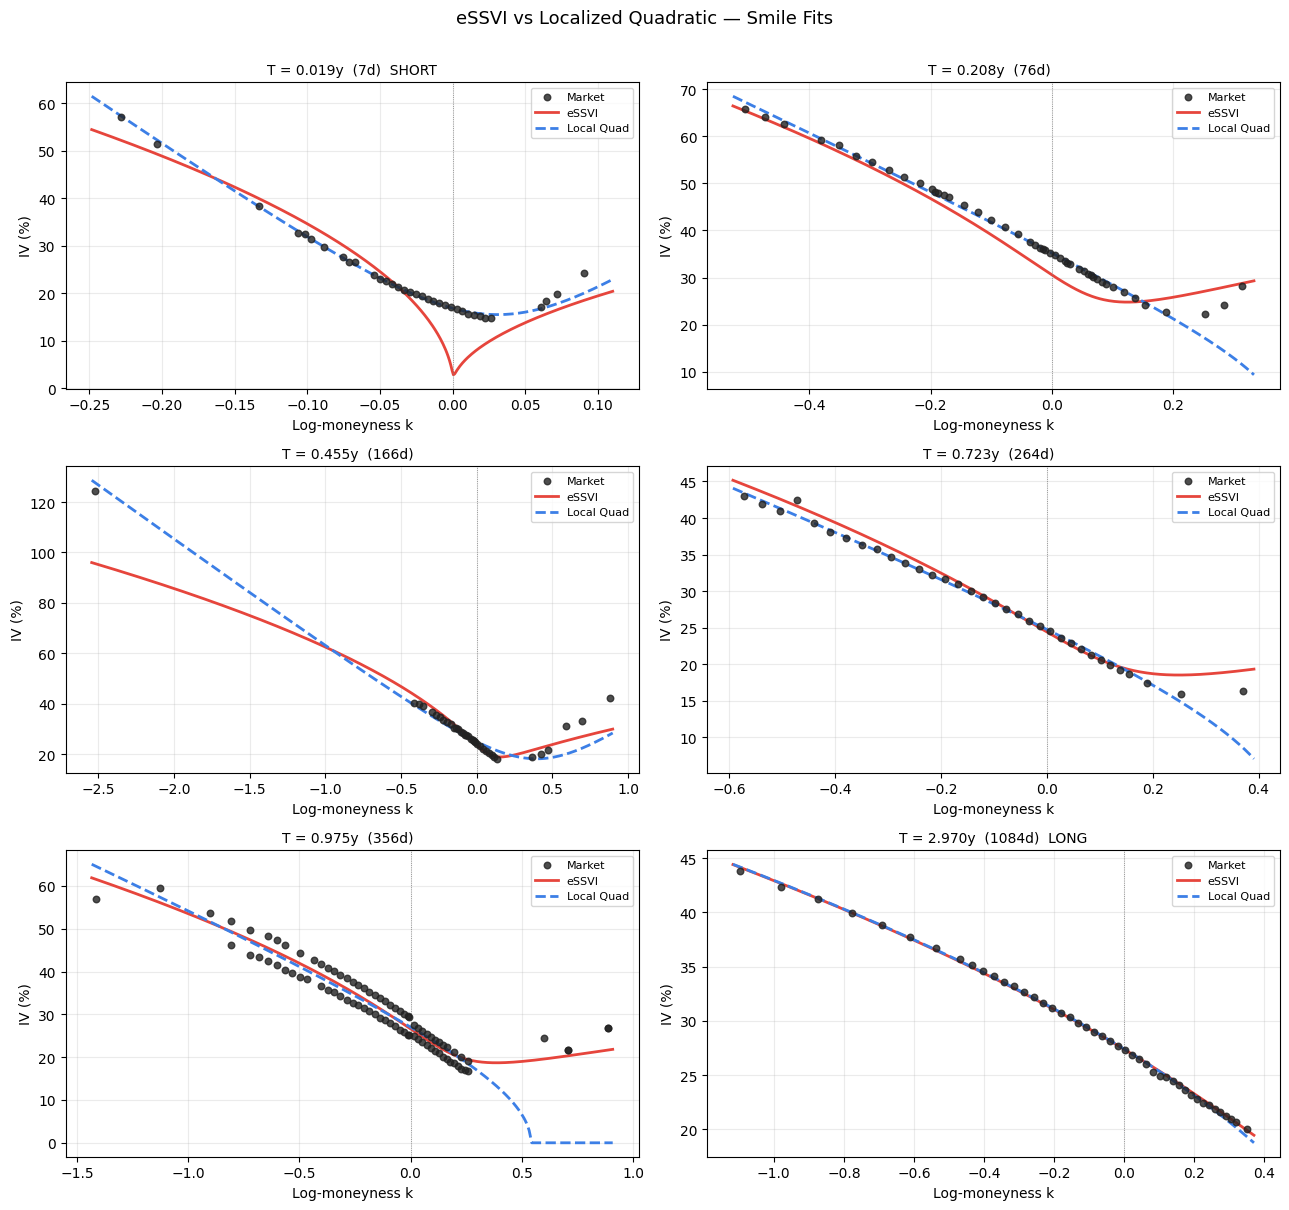

In [14]:
plot_smile_comparison(df_smile, fit_essvi, fit_local, n_slices=6)


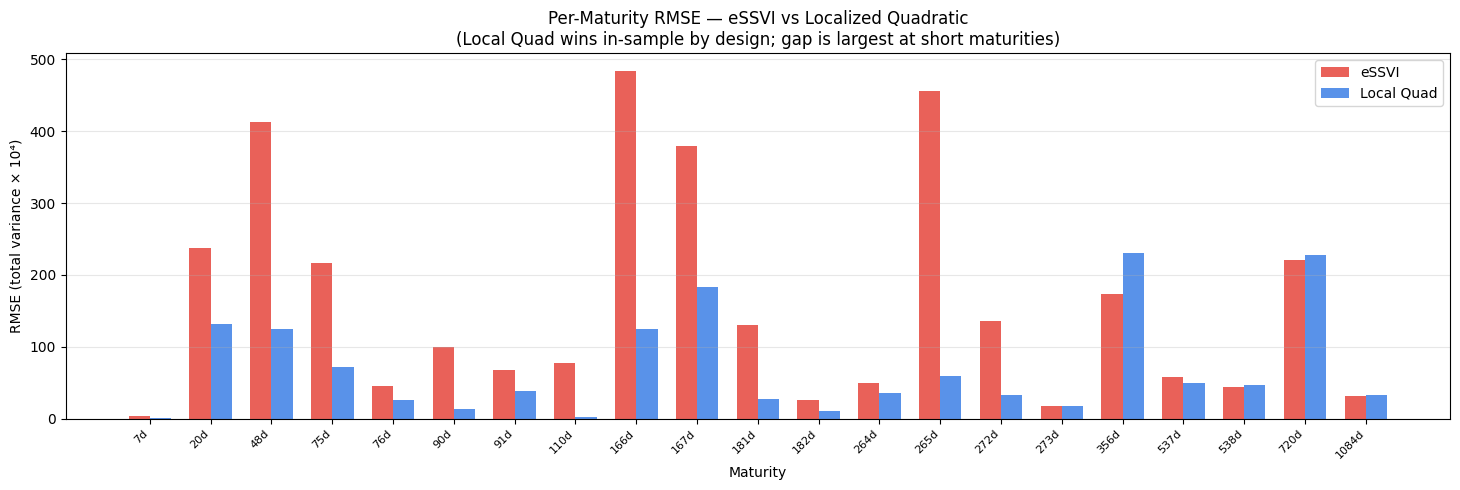

In [15]:
plot_rmse_comparison(df_smile, fit_essvi, fit_local)


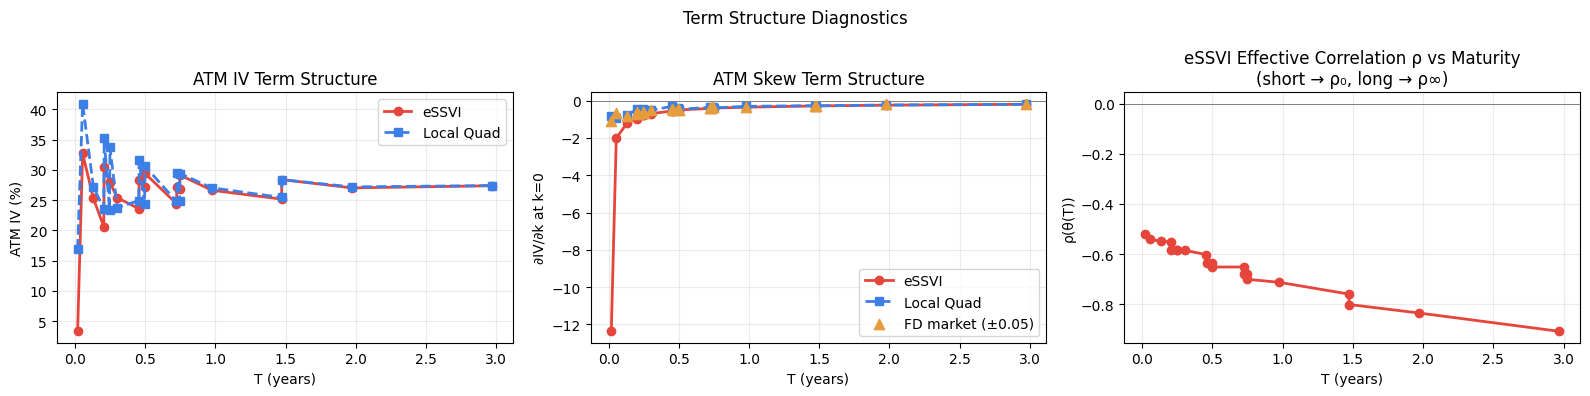

In [16]:
plot_term_structure_comparison(fit_essvi, fit_local, df_smile=df_smile, dk_band=0.05)

In [17]:
fd_skew = compute_fd_atm_skew(df_smile)
fd_skew

,T_days,T,fd_atm_skew,n_strikes
0,7,0.019178,-1.092541,19
1,20,0.054795,-0.686371,45
2,48,0.131507,-0.841584,30
3,75,0.205479,-0.612146,25
4,76,0.208219,-0.736354,12
5,90,0.246575,-0.606805,5
6,91,0.249315,-0.656376,3
7,110,0.301370,-0.508703,5
8,166,0.454795,-0.465340,7
9,167,0.457534,-0.497711,5


In [18]:
fit_local["summary"]

,T_days,T,a,b,c,atm_iv,atm_skew,rmse,mae,n_strikes
0,7,0.019178,0.000545,-0.005389,0.087106,0.168593,-0.833396,0.000079,0.000041,35
1,20,0.054795,0.009198,-0.042201,0.059062,0.409708,-0.939898,0.013164,0.010691,163
2,48,0.131507,0.009699,-0.055362,0.073891,0.271568,-0.775093,0.012488,0.009301,98
3,75,0.205479,0.011441,-0.044304,0.077966,0.235963,-0.456874,0.007188,0.002832,88
4,76,0.208219,0.025797,-0.097171,0.075472,0.351988,-0.662913,0.002615,0.001321,47
5,90,0.246575,0.013423,-0.051912,0.130833,0.233318,-0.451169,0.001334,0.001019,24
6,91,0.249315,0.028362,-0.088704,0.131483,0.337286,-0.527433,0.003855,0.002839,19
7,110,0.301370,0.016996,-0.074418,0.054509,0.237477,-0.519905,0.000202,0.000159,16
8,166,0.454795,0.028219,-0.067470,0.085453,0.249094,-0.297786,0.012445,0.006554,36
9,167,0.457534,0.045756,-0.114336,0.058767,0.316238,-0.395109,0.019872,0.010371,41


In [19]:
import inspect
print(inspect.signature(plot_power_law_term_structure))

(*methods, T_col, y_col, title='Power-Law Term Structure', x_label='Log(T)', y_label='Log(|y|)', labels=None, colors=None, colors_fit=None, markers=None, dashes=None, min_pts=3)


In [20]:
# Spot skew
plot_power_law_term_structure(
    fit_essvi["summary"], fit_local["summary"], fd_skew,
    T_col="T",
    y_col=["atm_skew", "atm_skew", "fd_atm_skew"],
    labels=["eSSVI", "Local Quad", "FD Market"],
    colors=[_C["eSSVI"], _C["local"], "#e69c3c"],
    colors_fit=["#f0a09a", "#9ac4f0", "#f0cfa0"],
    title="ATM Spot Skew — Power-Law Term Structure",
    x_label="Log(T)", y_label="Log(|ATM Skew|)",
)


In [ ]:
fwd = compute_atm_forward_skew(fit_essvi, fit_local, df_smile=df_smile)

plot_power_law_term_structure(
    fwd["eSSVI"], fwd["local"], fwd["fd"],
    T_col="T_mid",
    y_col="fwd_skew",
    labels=["eSSVI fwd", "Local Quad fwd", "FD Market fwd"],
    colors=[_C["eSSVI"], _C["local"], "#e69c3c"],
    colors_fit=["#f0a09a", "#9ac4f0", "#f0cfa0"],
    title="ATM Forward Skew — Power-Law Term Structure",
    x_label="Log(T_mid = √(T₁·T₂))", y_label="Log(|Fwd Skew|)",
)